In [11]:
import numpy as np
from tqdm import tqdm 
import steady_solver as ss 
import matplotlib.pyplot as plt 


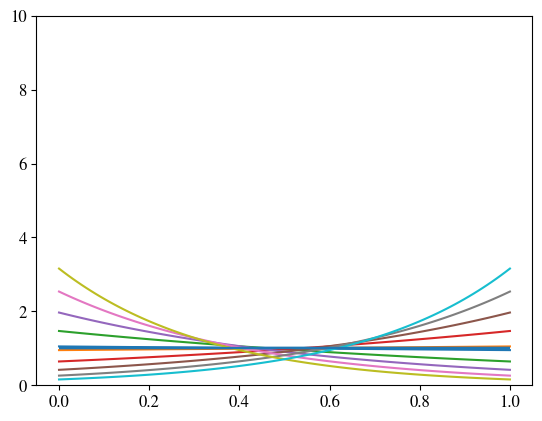

In [12]:
x = np.linspace(0, 1, 100)

def exp_down(x, b):
    return (b*np.exp(-b*x))/(1 - np.exp(-b))

def exp_up(x, b):
    return (b*np.exp(b*x))/(np.exp(b) - 1)

for b in np.linspace(0.1, 3.0, 5):
    y1 = exp_down(x, b)
    y2 = exp_up(x, b)

    plt.plot(x, y1)
    plt.hlines(np.mean(y1), x.min(), x.max())
    plt.plot(x, y2)
    plt.hlines(np.mean(y2), x.min(), x.max())
    plt.ylim(0, 10)
    # plt.show()

In [13]:


def sensitivity_search_exponential(beta_min=0.1, beta_max=3.0, chi_=0.1, N=10, n=5, mesh_file="./files/1D_mesh.msh"):
    taus = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    betas = np.linspace(beta_min, beta_max, n)
    sensitivities = np.zeros((N, N))
    meshcontext = ss.get_meshcontext(mesh_file)
    # loop over taus and gammas:
    for i in tqdm(range(N)):
        for j in range(N):
            tau = taus[i]
            gamma = gammas[j]
            chii_ref = ss.get_homogeneous_chii(tau, gamma, chi_)
            samples = n**2
            relative_drawdowns = np.zeros(samples)
            index = 0
            for k in range(n):
                for l in range(n):
                    delta = lambda x_: ss.exp_down(x_, betas[k])
                    kappa = lambda x_: ss.exp_up(x_, betas[l])
                    mesh, uh = ss.solver(meshcontext, tau, gamma, chi_, delta=delta, kappa=kappa, order=1)
                    domain, solution = ss.extract_solution_from_objects(mesh, uh, order=1)
                    chii = solution[0]
                    #print(f"tau:{tau:.3f}, gamma:{gamma:.3f}, index:{index}, chii:{chii:.3f}, chii_ref:{chii_ref:.3f}, rdd:{(chii_ref - chii)/(1 - chii_ref):.3f}")
                    relative_drawdowns[index] = (chii_ref - chii)/(1 - chii_ref)
                    index += 1
            sensitivities[i, j] = np.sqrt(np.sum(relative_drawdowns**2)/samples)
    return taus, gammas, sensitivities.T

taus, gammas, sensitivities = sensitivity_search_exponential(N=50, n=5)
np.savetxt('./files/sensitivities.txt', sensitivities, delimiter=";")
    

Info    : Reading './files/1D_mesh.msh'...
Info    : 3 entities
Info    : 101 nodes
Info    : 101 elements
Info    : Done reading './files/1D_mesh.msh'


100%|██████████| 50/50 [09:30<00:00, 11.40s/it]


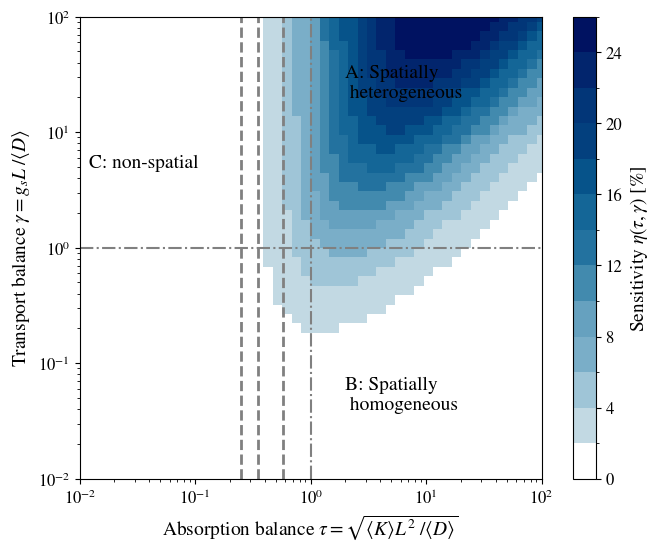

In [28]:
import sys 
sys.path.append('../../modules')
import matplotlib_config as mconf
colorI, colorII, colorIII = mconf.set_standard_layout()


sensitivity = 100*np.loadtxt('./files/sensitivities.txt', delimiter=';')
N = len(sensitivity)

taus   = np.exp(np.linspace(np.log(0.01), np.log(100), N))
gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
bounds = (0, 26, 14) # color map boundaries, 0-26% sensitivity, 14 steps 


# FULL PLOT
fig = plt.figure(figsize=(8,6))
cmap, norm = mconf.my_cmap(*bounds)
im = plt.pcolor(taus, gammas, sensitivity, shading='nearest', cmap=cmap, norm=norm)
cbar = plt.colorbar(im)

lines = [0.248, 0.352, 0.570] #1%, 2%, 5% relative error
for line in lines:
    plt.vlines(line, 0.01, 100, color='grey', linestyle='--', linewidth=2)
#  
plt.text(0.012, 5, 'C: non-spatial', fontsize=14, color='black')
plt.text(2, 0.04, 'B: Spatially \n homogeneous', fontsize=14, color='black')
plt.text(2, 20, 'A: Spatially \n heterogeneous', fontsize=14, color='black')
#
cbar.set_label(r'Sensitivity $\eta(\tau, \gamma)$ [%]')
plt.xlabel(r'Absorption balance $\tau = \sqrt{\langle K \rangle L^2 \; / \langle D\rangle}$')
plt.ylabel(r'Transport balance $\gamma = g_s L \; / \langle D \rangle$')
plt.hlines(1, 0.01, 100, color='grey', linestyle='-.')
plt.vlines(1, 0.01, 100, color='grey', linestyle='-.')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.01, 100)
plt.ylim(0.01, 100)
plt.gca().set_aspect('equal')
plt.show()